<a href="https://colab.research.google.com/github/sajeeb15/streamlit-regression-app/blob/main/Online_Retail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier

import pickle

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Machine_Learning/online_retail.csv')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [5]:
df.describe(include='all')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900,4070,4223,NaN,23260,NaN,NaN,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,2011-10-31 14:41:00,NaN,NaN,United Kingdom
freq,1114,2313,2369,NaN,1114,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,NaN,4.611114,15287.690570,NaN
std,NaN,NaN,NaN,218.081158,NaN,96.759853,1713.600303,NaN
min,NaN,NaN,NaN,-80995.000000,NaN,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,NaN,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,NaN,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,NaN,4.130000,16791.000000,NaN


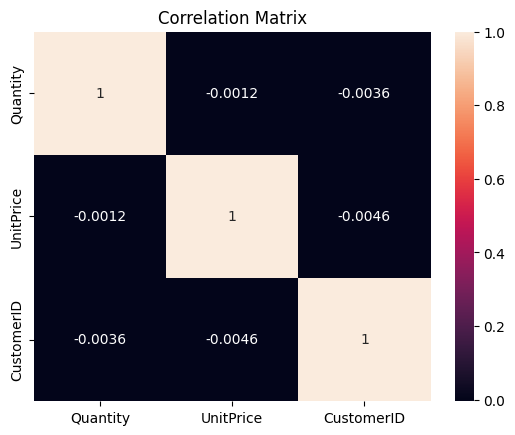

In [6]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

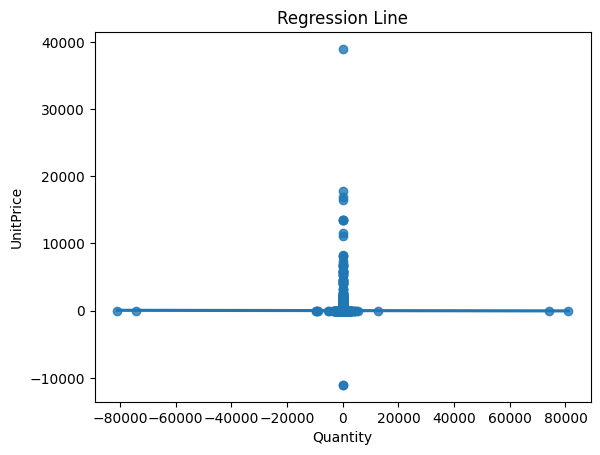

In [7]:
sns.regplot(x='Quantity', y='UnitPrice', data=df)
plt.title("Regression Line")
plt.show()

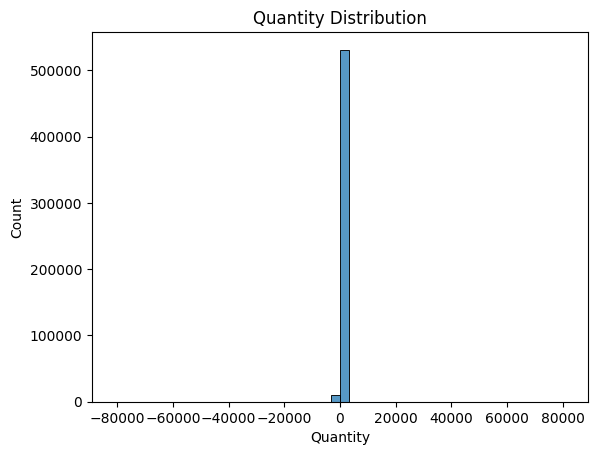

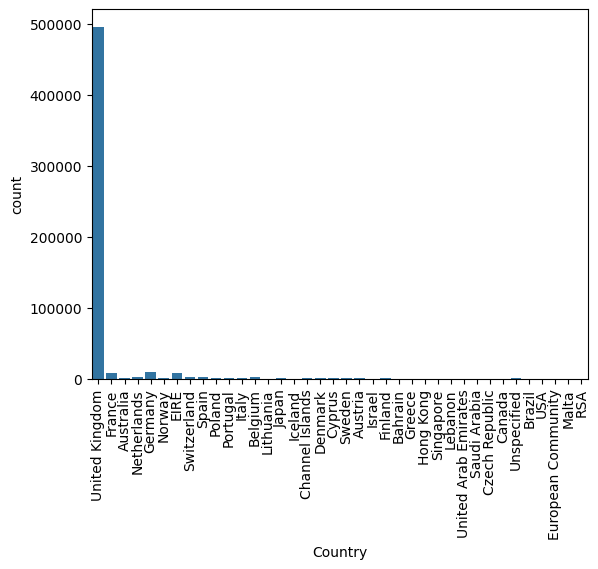

In [8]:
sns.histplot(df['Quantity'], bins=50)
plt.title("Quantity Distribution")
plt.show()

sns.countplot(x='Country', data=df)
plt.xticks(rotation=90)
plt.show()

In [9]:
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

In [10]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df['HighValue'] = df['TotalPrice'].apply(lambda x: 1 if x > 100 else 0)

In [11]:
le = LabelEncoder()
df['Country'] = le.fit_transform(df['Country'])

In [12]:
scaler = StandardScaler()

X = df[['Quantity','UnitPrice','Country']]
y = df['HighValue']

X_scaled = scaler.fit_transform(X)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [14]:
models = {
    "Logistic Regression": LogisticRegression(),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "AdaBoost": AdaBoostClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(name, "Accuracy:", accuracy_score(y_test, pred))

Logistic Regression Accuracy: 0.9833429226285358
SVM Accuracy: 0.9880306731685232
Decision Tree Accuracy: 0.9999811358127163
Random Forest Accuracy: 0.9999151111572235
KNN Accuracy: 0.9991511115722357
AdaBoost Accuracy: 0.9963686439478971


In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [32]:
X = df[['Quantity', 'UnitPrice', 'Country']]
y = df['HighValue']

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [35]:
clf.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [36]:
# Define classifiers
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "AdaBoost": AdaBoostClassifier()
}

# Train each classifier and collect results
results = []

for name, clf in classifiers.items():

    # Train model
    clf.fit(X_train_scaled, y_train)

    # Predict
    y_pred = clf.predict(X_test_scaled)

    # Metrics (safe for binary + multiclass)
    acc       = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1        = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    # Store results
    results.append({
        'Model'     : name,
        'Accuracy'  : round(acc, 4),
        'Precision' : round(precision, 4),
        'Recall'    : round(recall, 4),
        'F1 Score'  : round(f1, 4)
    })

    print(f'{name:22s} -> Accuracy: {acc:.4f} | F1: {f1:.4f}')

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Sort by Accuracy
results_df = results_df.sort_values(by='Accuracy', ascending=False)

# Reset index for ranking
results_df = results_df.reset_index(drop=True)
results_df.index += 1

print('\n✅ All models trained!\n')
print(results_df)

Logistic Regression    -> Accuracy: 0.9833 | F1: 0.9818
SVM                    -> Accuracy: 0.9874 | F1: 0.9868
Decision Tree          -> Accuracy: 1.0000 | F1: 1.0000
Random Forest          -> Accuracy: 0.9999 | F1: 0.9999
KNN                    -> Accuracy: 0.9991 | F1: 0.9991
AdaBoost               -> Accuracy: 0.9964 | F1: 0.9963

✅ All models trained!

                 Model  Accuracy  Precision  Recall  F1 Score
1        Decision Tree    1.0000     1.0000  1.0000    1.0000
2        Random Forest    0.9999     0.9999  0.9999    0.9999
3                  KNN    0.9991     0.9991  0.9991    0.9991
4             AdaBoost    0.9964     0.9963  0.9964    0.9963
5                  SVM    0.9874     0.9865  0.9874    0.9868
6  Logistic Regression    0.9833     0.9814  0.9833    0.9818


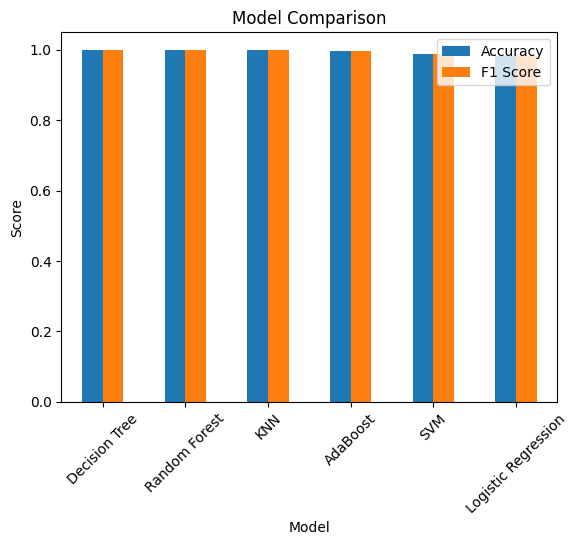

In [37]:
import matplotlib.pyplot as plt

results_df.set_index("Model")[["Accuracy", "F1 Score"]].plot(kind="bar")
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

In [38]:
best_model_name = results_df.iloc[0]["Model"]
print("Best Model:", best_model_name)

Best Model: Decision Tree


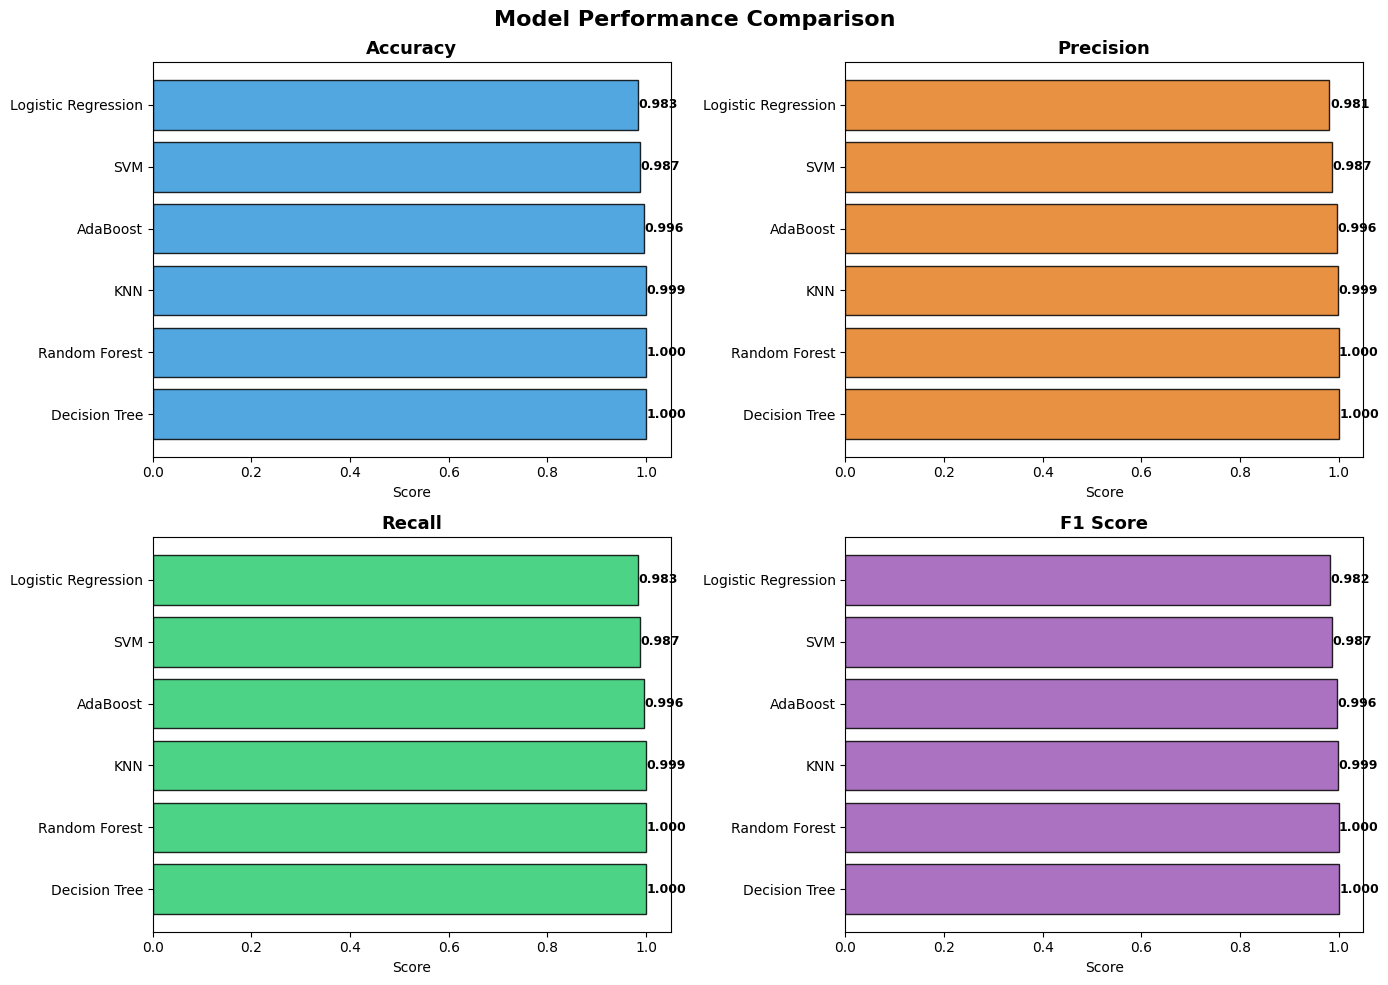

In [41]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
models = results_df['Model'].tolist()

# Colors (one for each subplot)
colors = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (metric, color) in enumerate(zip(metrics, colors)):

    values = results_df[metric].tolist()

    bars = axes[i].barh(models, values, color=color, alpha=0.85, edgecolor='black')

    # Add value labels
    for bar, val in zip(bars, values):
        axes[i].text(val + 0.001,
                     bar.get_y() + bar.get_height()/2,
                     f'{val:.3f}',
                     va='center', ha='left',
                     fontsize=9, fontweight='bold')

    axes[i].set_title(metric, fontsize=13, fontweight='bold')
    axes[i].set_xlim(0, 1.05)   # safer than 0.85–1.02
    axes[i].set_xlabel('Score')

plt.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

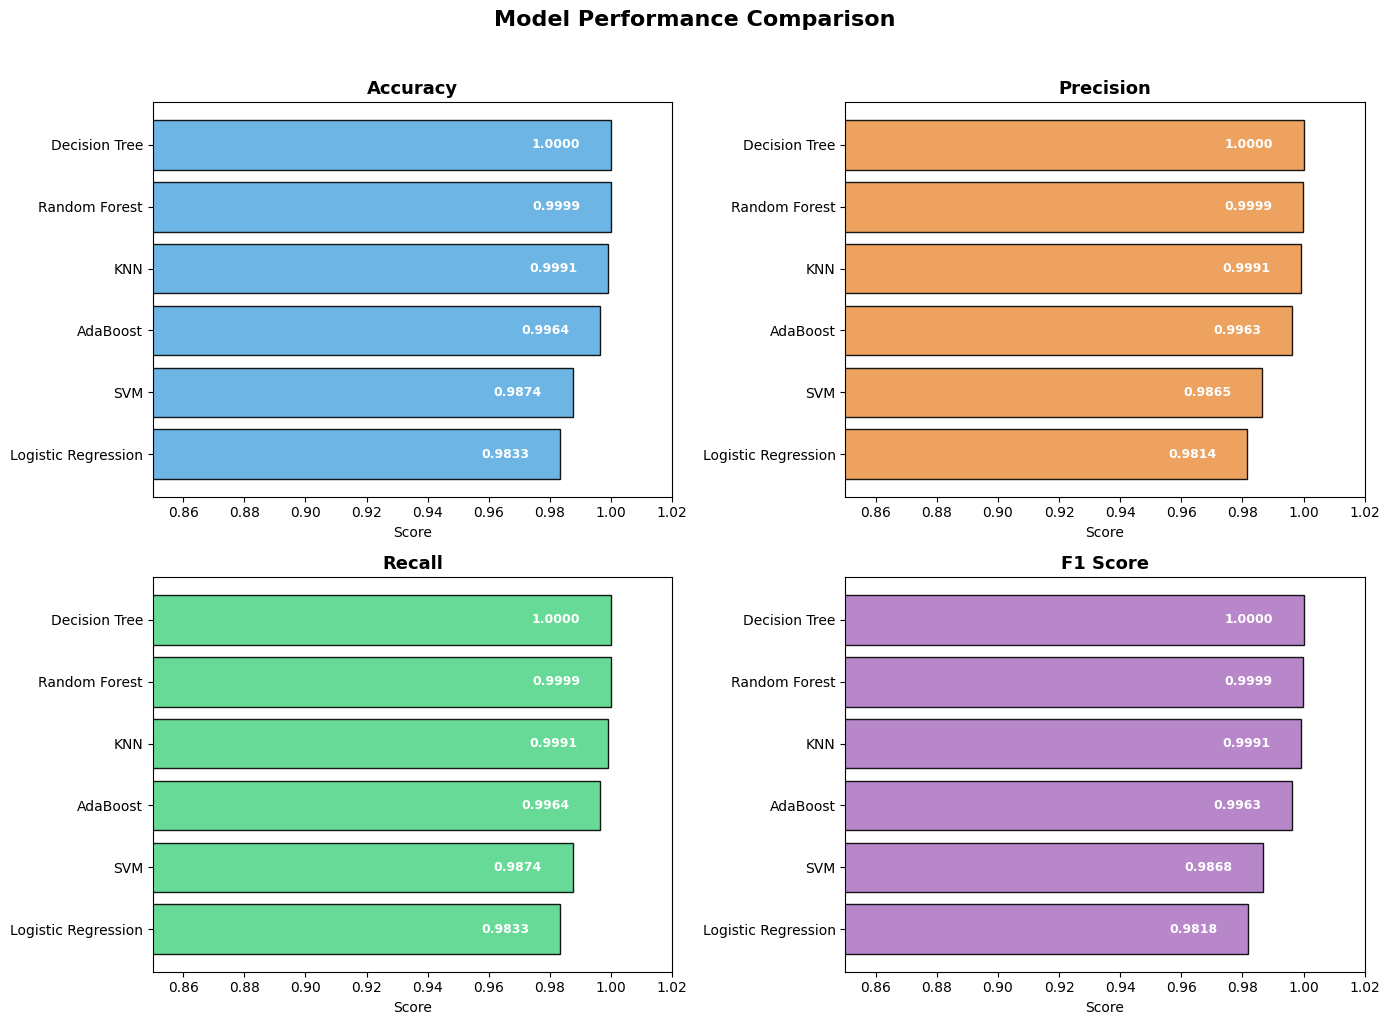

In [42]:
results_df = results_df.sort_values(by="Accuracy", ascending=True)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
titles  = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
colors  = ['#5DADE2', '#EB984E', '#58D68D', '#AF7AC5']

models = results_df['Model'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):

    values = results_df[metric].tolist()

    bars = axes[i].barh(models, values,
                        color=colors[i],
                        edgecolor='black',
                        alpha=0.9)

    # Add labels inside bars (like your image)
    for bar, val in zip(bars, values):
        axes[i].text(val - 0.01,
                     bar.get_y() + bar.get_height()/2,
                     f'{val:.4f}',
                     va='center', ha='right',
                     color='white', fontsize=9, fontweight='bold')

    axes[i].set_title(titles[i], fontsize=13, fontweight='bold')
    axes[i].set_xlim(0.85, 1.02)   # match your style
    axes[i].set_xlabel('Score')

# Main title
plt.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

In [43]:
results_df.style\
    .background_gradient(subset=['Accuracy', 'Precision', 'Recall', 'F1 Score'],
                         cmap='YlGn')\
    .set_caption('📊 Model Comparison — sorted by Accuracy')\
    .format({'Accuracy': '{:.4f}', 'Precision': '{:.4f}',
             'Recall': '{:.4f}', 'F1 Score': '{:.4f}'})

,Model,Accuracy,Precision,Recall,F1 Score
6,Logistic Regression,0.9833,0.9814,0.9833,0.9818
5,SVM,0.9874,0.9865,0.9874,0.9868
4,AdaBoost,0.9964,0.9963,0.9964,0.9963
3,KNN,0.9991,0.9991,0.9991,0.9991
2,Random Forest,0.9999,0.9999,0.9999,0.9999
1,Decision Tree,1.0000,1.0000,1.0000,1.0000


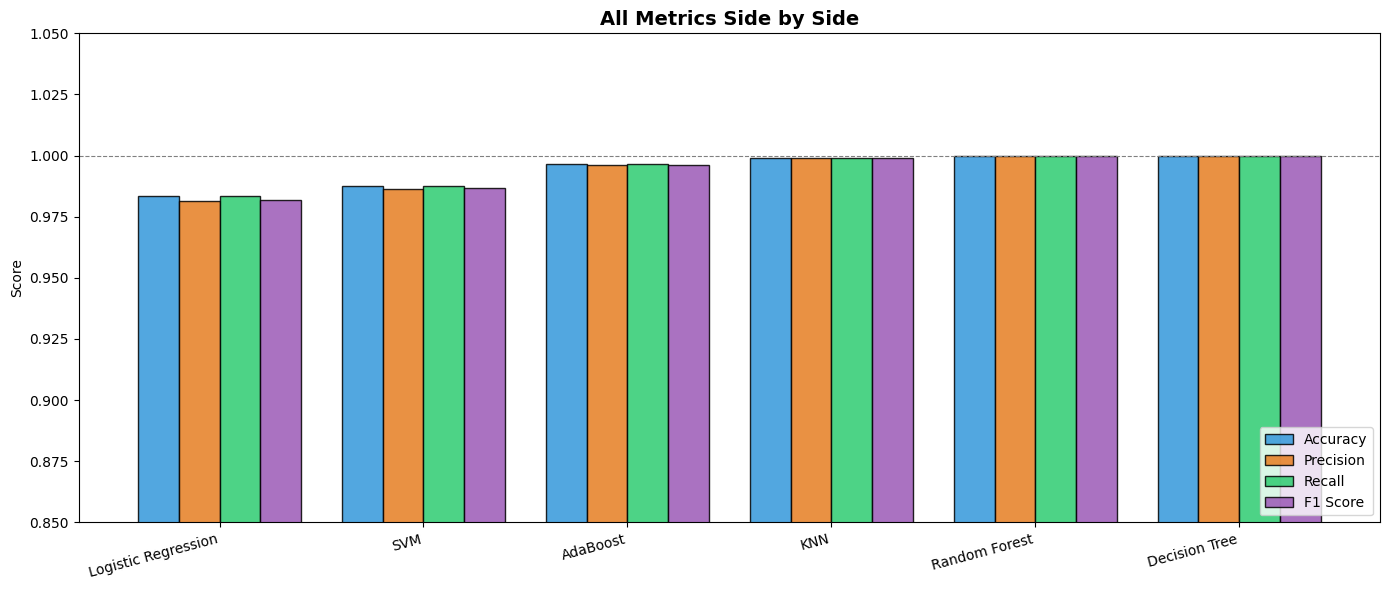

In [44]:
x      = np.arange(len(models))
width  = 0.2
colors = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6']

fig, ax = plt.subplots(figsize=(14, 6))

for i, (metric, color) in enumerate(zip(metrics, colors)):
    offset = (i - 1.5) * width
    ax.bar(x + offset, results_df[metric], width, label=metric,
           color=color, alpha=0.85, edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right', fontsize=10)
ax.set_ylim(0.85, 1.05)
ax.set_ylabel('Score')
ax.set_title('All Metrics Side by Side', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.axhline(y=1.0, color='grey', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

In [46]:
from sklearn.metrics import confusion_matrix

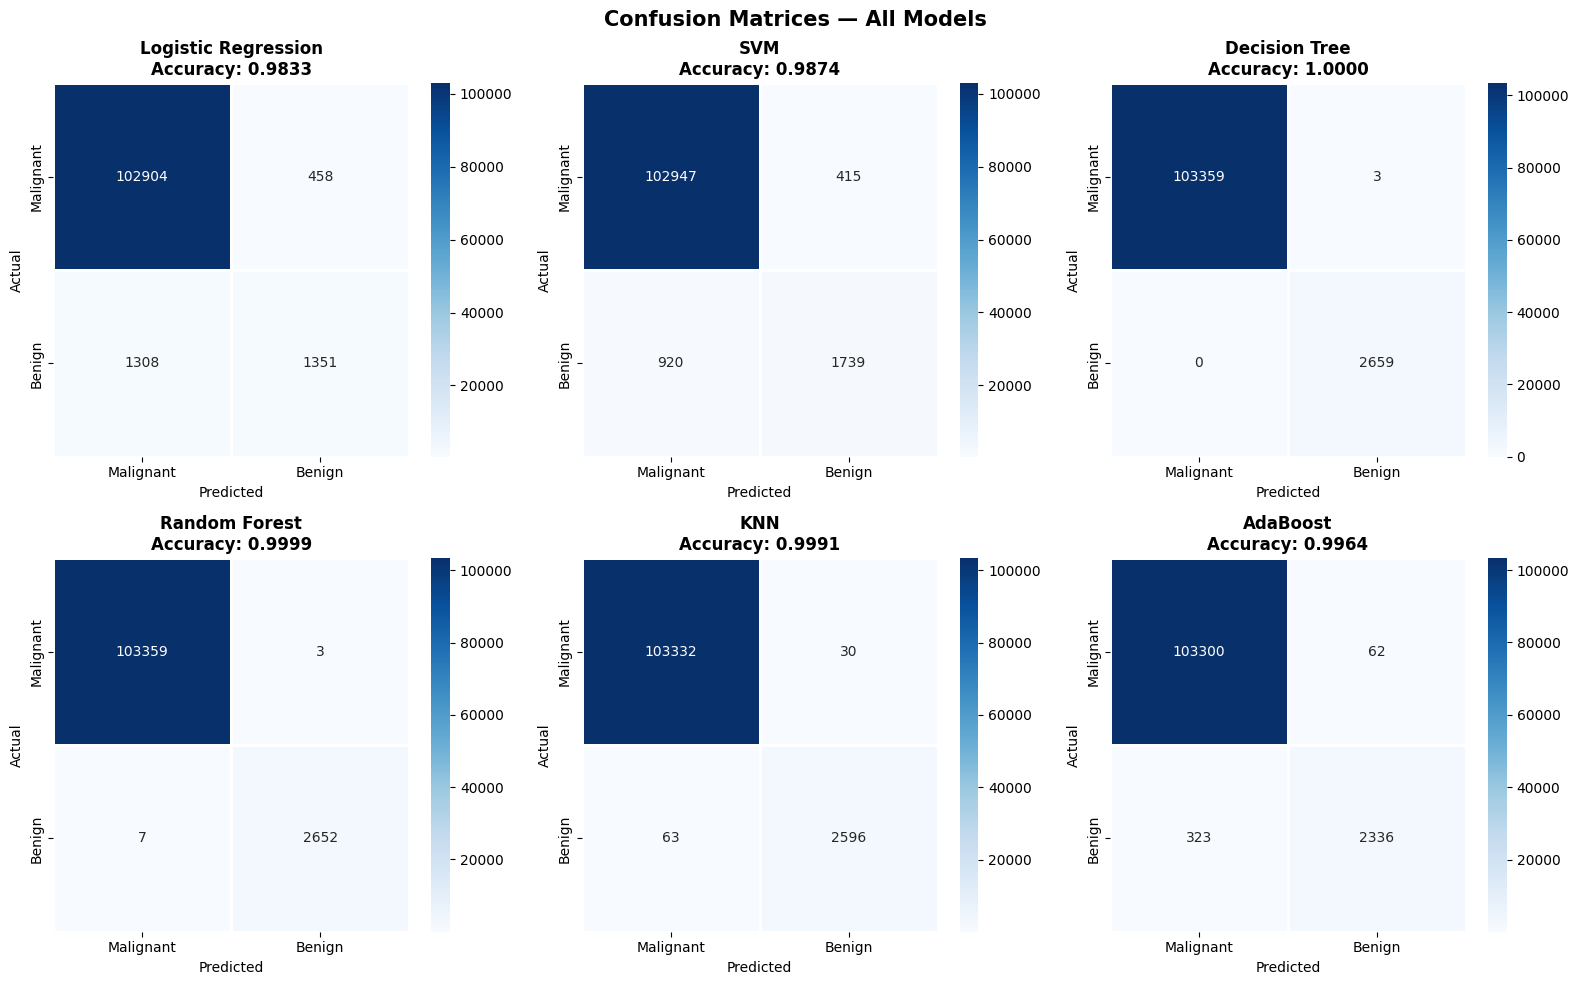

In [47]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (name, clf) in enumerate(classifiers.items()):
    # Get predictions
    y_pred = clf.predict(X_test_scaled)

    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Malignant', 'Benign'],
                yticklabels=['Malignant', 'Benign'],
                ax=axes[i], linewidths=1)

    acc = accuracy_score(y_test, y_pred)
    axes[i].set_title(f'{name}\nAccuracy: {acc:.4f}', fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [49]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import joblib

# Create pipeline
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

In [50]:
import joblib
from sklearn.metrics import r2_score

# 1. Fit and Predict using only the Linear Regression pipeline
lr_pipeline.fit(X_train, y_train)
preds = lr_pipeline.predict(X_test)

# 2. Evaluate performance
score = r2_score(y_test, preds)

# 3. Save the model to a file
joblib.dump(lr_pipeline, 'linear_regression_model.pkl')

print("Linear Regression Analysis Complete")
print("-" * 30)
print(f"R² Score: {score:.4f}")
print("Model saved to: linear_regression_model.pkl")

Linear Regression Analysis Complete
------------------------------
R² Score: 0.0419
Model saved to: linear_regression_model.pkl


In [52]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier())
])

pipeline.fit(X_train, y_train)

joblib.dump(pipeline, "model.pkl")

['model.pkl']

In [53]:
from google.colab import files
files.download("model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>